## About Dataset

#### Context
- "Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

#### Content
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents

## Exploration & Data loading

In [92]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [93]:
import os
os.getcwd()
os.listdir()

['charges_distribution_churn.png',
 'EDA.ipynb',
 'tenure_contract_boxplot.png',
 'tenure_contract_churn.png',
 'demographics_churn.png']

In [94]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')
df.shape

(7043, 21)

In [95]:
# df1 = pd.read_csv("/Users/riadanas/Desktop/Telco Customer Churn MLE/data/processed/telco_churn_processed.csv")
# df1.head(1)

In [96]:
# pd.set_option('display.max_columns', None)  # Show all columns in the DataFrame
# pd.set_option('display.max_rows', None)     # Show all rows in the DataFrame

In [97]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [99]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [100]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

- based on the .describe (and exploration) we can see that most categorical variables have between 2, 3, or 4 categories 
- So for those that only have 2 (binary) let's just replace by 0 and 1
- For those that have 3 or 4 we can do One-Hot encoding

In [101]:
df['SeniorCitizen'].unique()

array([0, 1])

## Manipulation and Cleaning

In [102]:
# drop customerID column as it is not useful for modeling
df = df.drop('customerID', axis=1)

In [103]:
# convert TotalCharges to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [104]:
df[df['TotalCharges'].isnull()][['tenure','MonthlyCharges','TotalCharges']]
# # fill missing TotalCharges with MonthlyCharges * tenure
# df['TotalCharges'] = df.apply(lambda row: row['MonthlyCharges'] * row['tenure'] if pd.isnull(row['TotalCharges']) else row['TotalCharges'], axis=1)

# drop rows with null TotalCharges (11 rows)
df.dropna(subset=['TotalCharges'],inplace=True)

In [105]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [106]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## EDA

In [107]:
df.head(1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


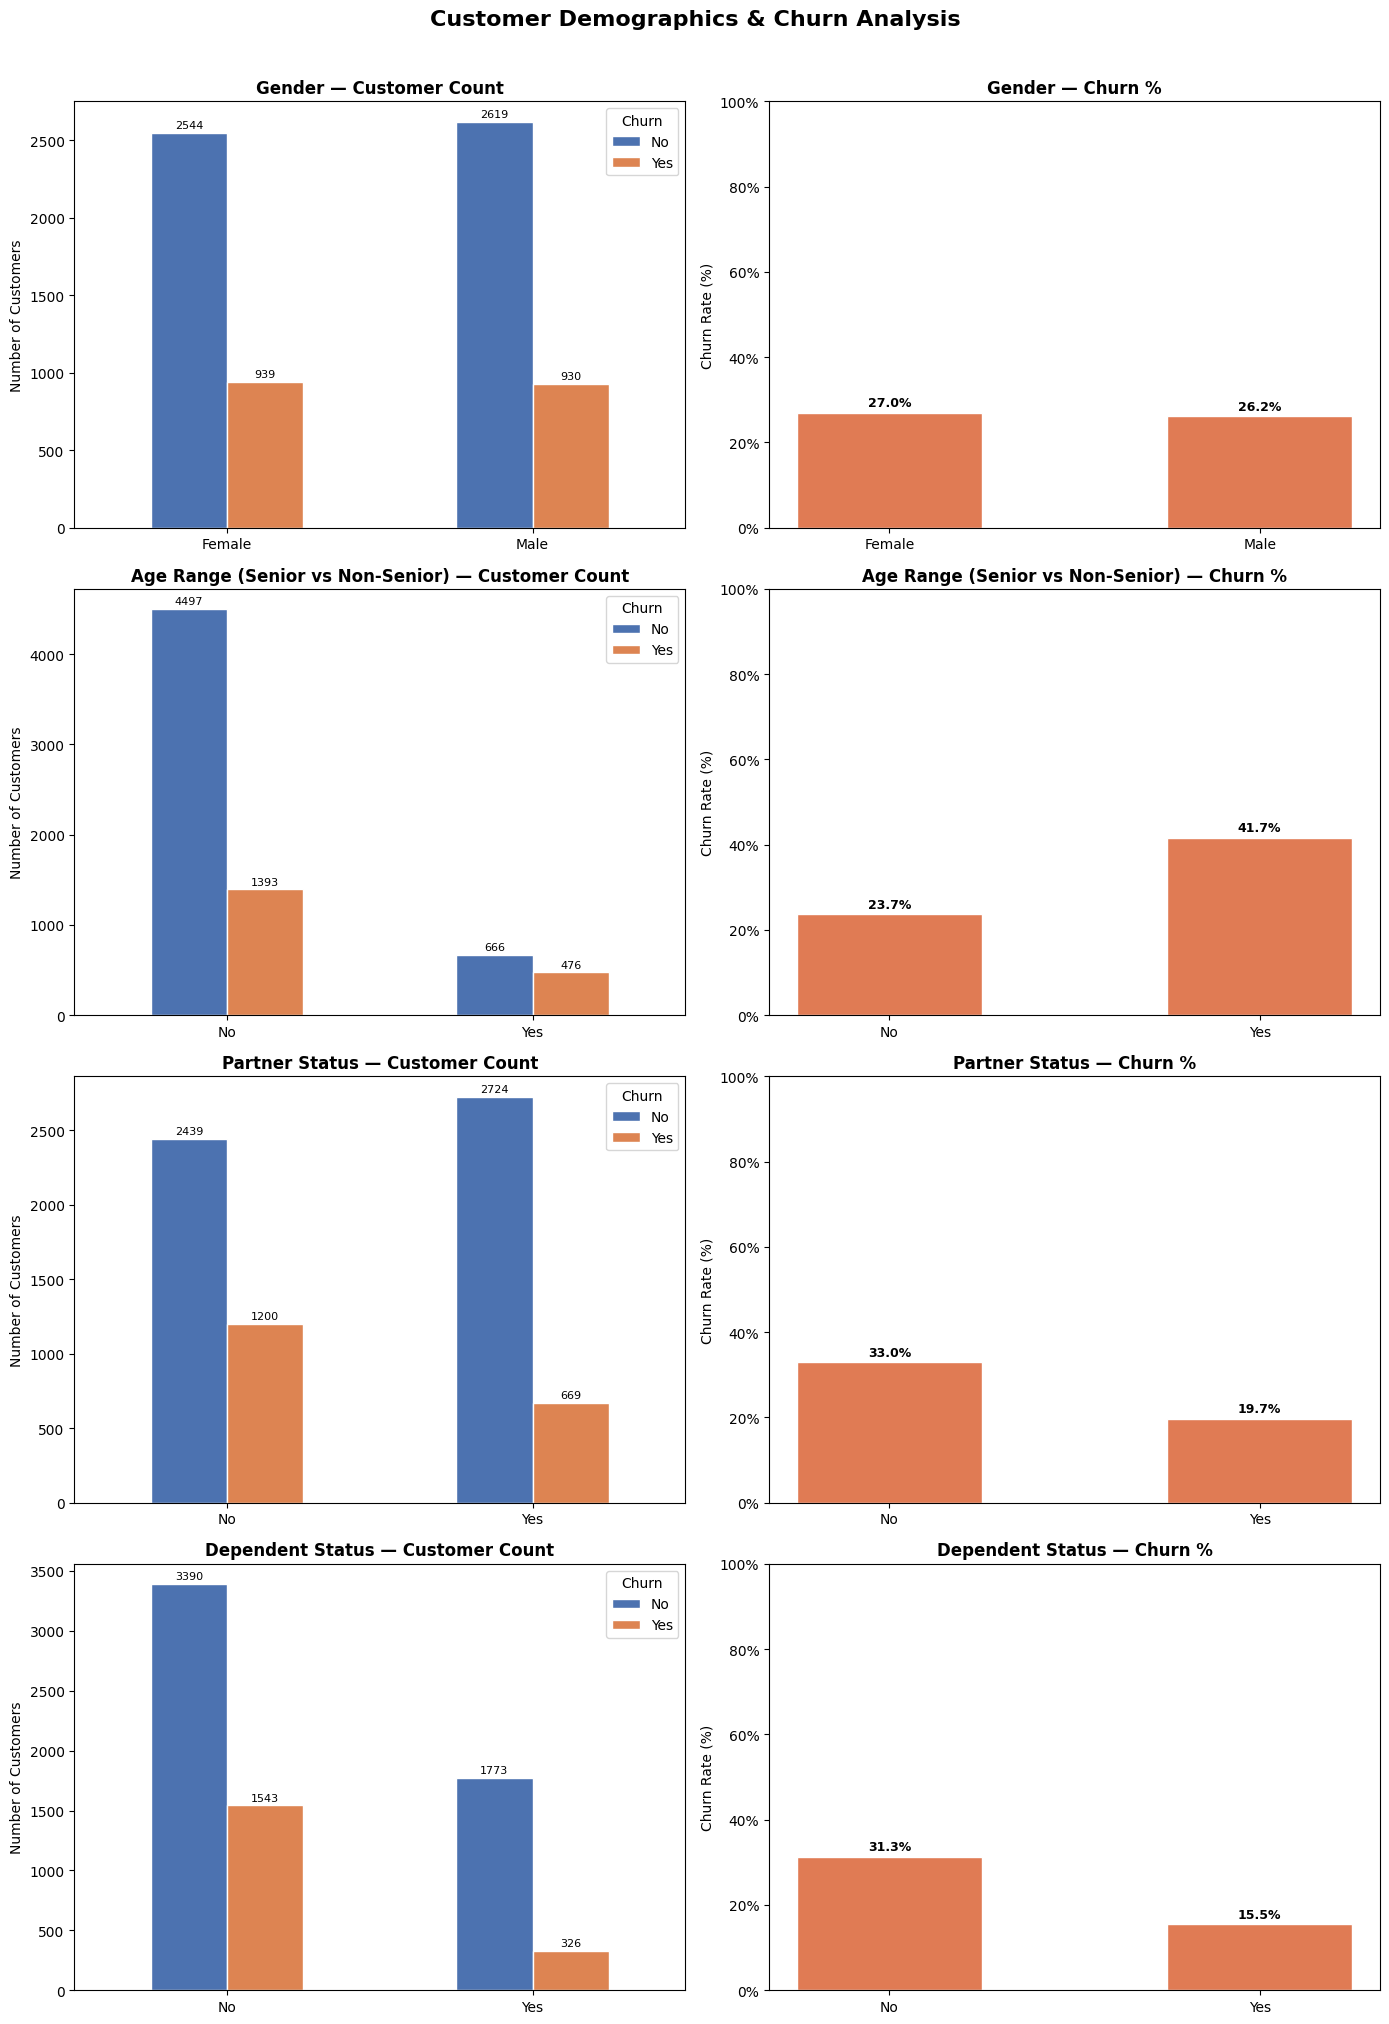

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns


fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle('Customer Demographics & Churn Analysis', fontsize=16, fontweight='bold', y=1.01)

colors = ['#4C72B0', '#DD8452']  # Blue = No Churn, Orange = Churn

# ── Helper: count plot + churn % side by side ──────────────────────────────
def plot_pair(ax_count, ax_churn, col, title):
    # Left: customer count by category, split by churn
    churn_counts = df.groupby([col, 'Churn']).size().unstack(fill_value=0)
    churn_counts.plot(kind='bar', ax=ax_count, color=colors, edgecolor='white', rot=0)
    ax_count.set_title(f'{title} — Customer Count', fontweight='bold')
    ax_count.set_xlabel('')
    ax_count.set_ylabel('Number of Customers')
    ax_count.legend(title='Churn', labels=['No', 'Yes'])
    for container in ax_count.containers:
        ax_count.bar_label(container, fontsize=8, padding=2)

    # Right: churn % per category
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_rate.columns = [col, 'Churn_Rate']
    bars = ax_churn.bar(churn_rate[col], churn_rate['Churn_Rate'],
                        color='#e07b54', edgecolor='white', width=0.5)
    ax_churn.set_title(f'{title} — Churn %', fontweight='bold')
    ax_churn.set_xlabel('')
    ax_churn.set_ylabel('Churn Rate (%)')
    ax_churn.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax_churn.set_ylim(0, 100)
    for bar in bars:
        ax_churn.text(bar.get_x() + bar.get_width()/2,
                      bar.get_height() + 1.5,
                      f'{bar.get_height():.1f}%',
                      ha='center', fontsize=9, fontweight='bold')

# ── 1. Gender ───────────────────────────────────────────────────────────────
plot_pair(axes[0][0], axes[0][1], 'gender', 'Gender')

# ── 2. Senior Citizen ───────────────────────────────────────────────────────
plot_pair(axes[1][0], axes[1][1], 'SeniorCitizen', 'Age Range (Senior vs Non-Senior)')

# ── 3. Partner ──────────────────────────────────────────────────────────────
plot_pair(axes[2][0], axes[2][1], 'Partner', 'Partner Status')

# ── 4. Dependents ───────────────────────────────────────────────────────────
plot_pair(axes[3][0], axes[3][1], 'Dependents', 'Dependent Status')

plt.tight_layout()
plt.savefig('demographics_churn.png', dpi=150, bbox_inches='tight')
plt.show()

- Gender → Churn % is almost equal (~26%) — gender doesn't matter much
- Senior Citizens → Churn ~41% vs Non-Senior ~24% — seniors churn a lot more!
- Partner → Customers without a partner churn more (~33% vs ~20%)
- Dependents → Customers without dependents churn more (~31% vs ~15%)


- Key insight: Customers who are senior, single, and have no dependents are your highest churn risk group!

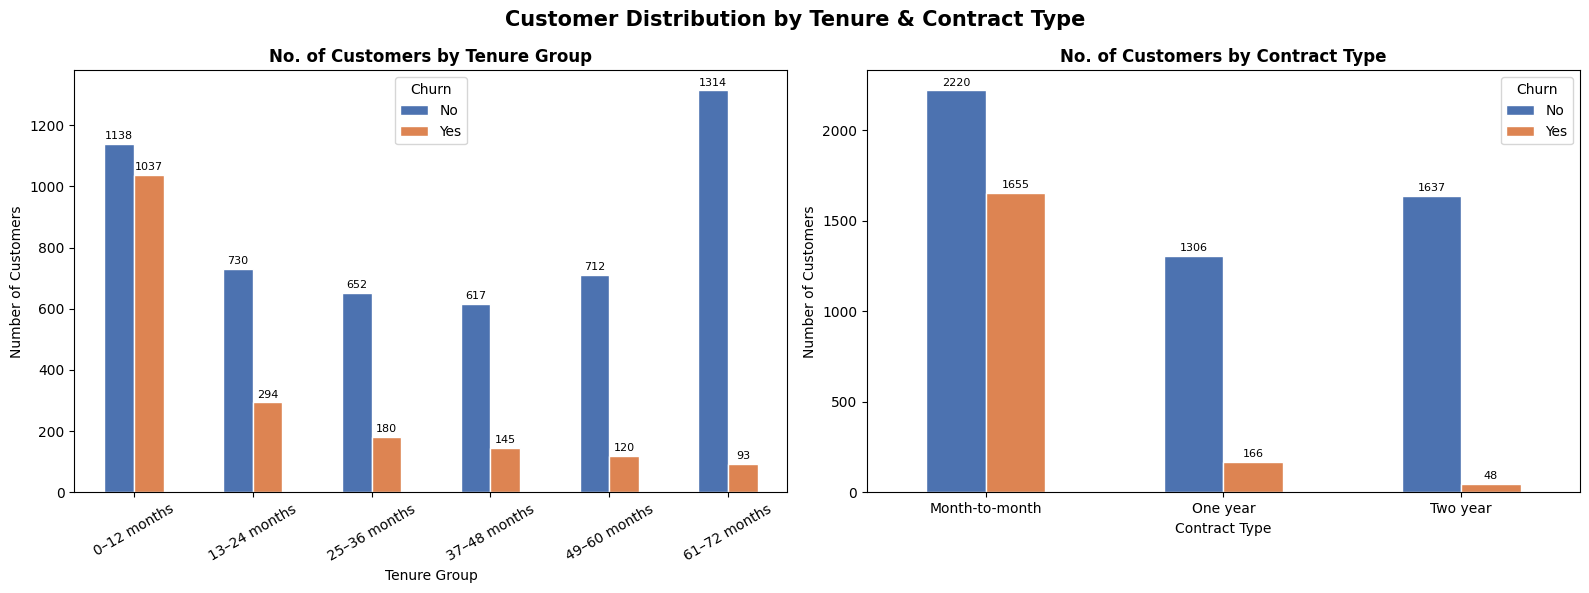

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Customer Distribution by Tenure & Contract Type', fontsize=15, fontweight='bold')

# ── 1. Tenure — group into bins ─────────────────────────────────────────────
tenure_bins = [0, 12, 24, 36, 48, 60, 72]
tenure_labels = ['0–12 months', '13–24 months', '25–36 months','37–48 months', '49–60 months', '61–72 months']

df['tenure_group'] = pd.cut(df['tenure'], bins=tenure_bins, labels=tenure_labels)

tenure_churn = df.groupby(['tenure_group', 'Churn'], observed=True).size().unstack(fill_value=0)

tenure_churn.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'],edgecolor='white', rot=30)
axes[0].set_title('No. of Customers by Tenure Group', fontweight='bold')
axes[0].set_xlabel('Tenure Group')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(title='Churn', labels=['No', 'Yes'])
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=8, padding=2)

# ── 2. Contract Type ─────────────────────────────────────────────────────────
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)

contract_churn.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'], edgecolor='white', rot=0)
axes[1].set_title('No. of Customers by Contract Type', fontweight='bold')
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Number of Customers')
axes[1].legend(title='Churn', labels=['No', 'Yes'])
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('tenure_contract_churn.png', dpi=150, bbox_inches='tight')
plt.show()

##### Insight Tenure Group 
- 0–12 months Highest churn — new customers leave the most1
- 3–24 monthsChurn starts dropping
- 61–72 months🟢Lowest churn — loyal long-term customers rarely leave

##### Insight Contract type
- Month-to-month By far the most churn —> easy to cancel/churn anytime
- One year -> Moderate churn
- Two year - > Almost no churn — committed customers

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

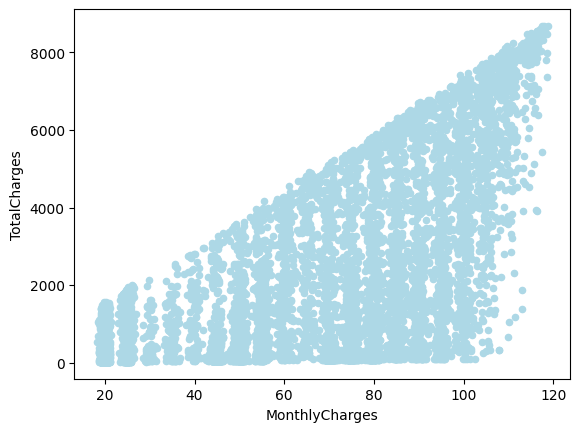

In [110]:
df[['MonthlyCharges', 'TotalCharges']].plot.scatter(x = 'MonthlyCharges',y='TotalCharges',color='lightblue')

- Insight -> total charges increases as the monthly bill for a customer increases.

/tmp/ipykernel_124017/1770504683.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0][1],
/tmp/ipykernel_124017/1770504683.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[1][1],


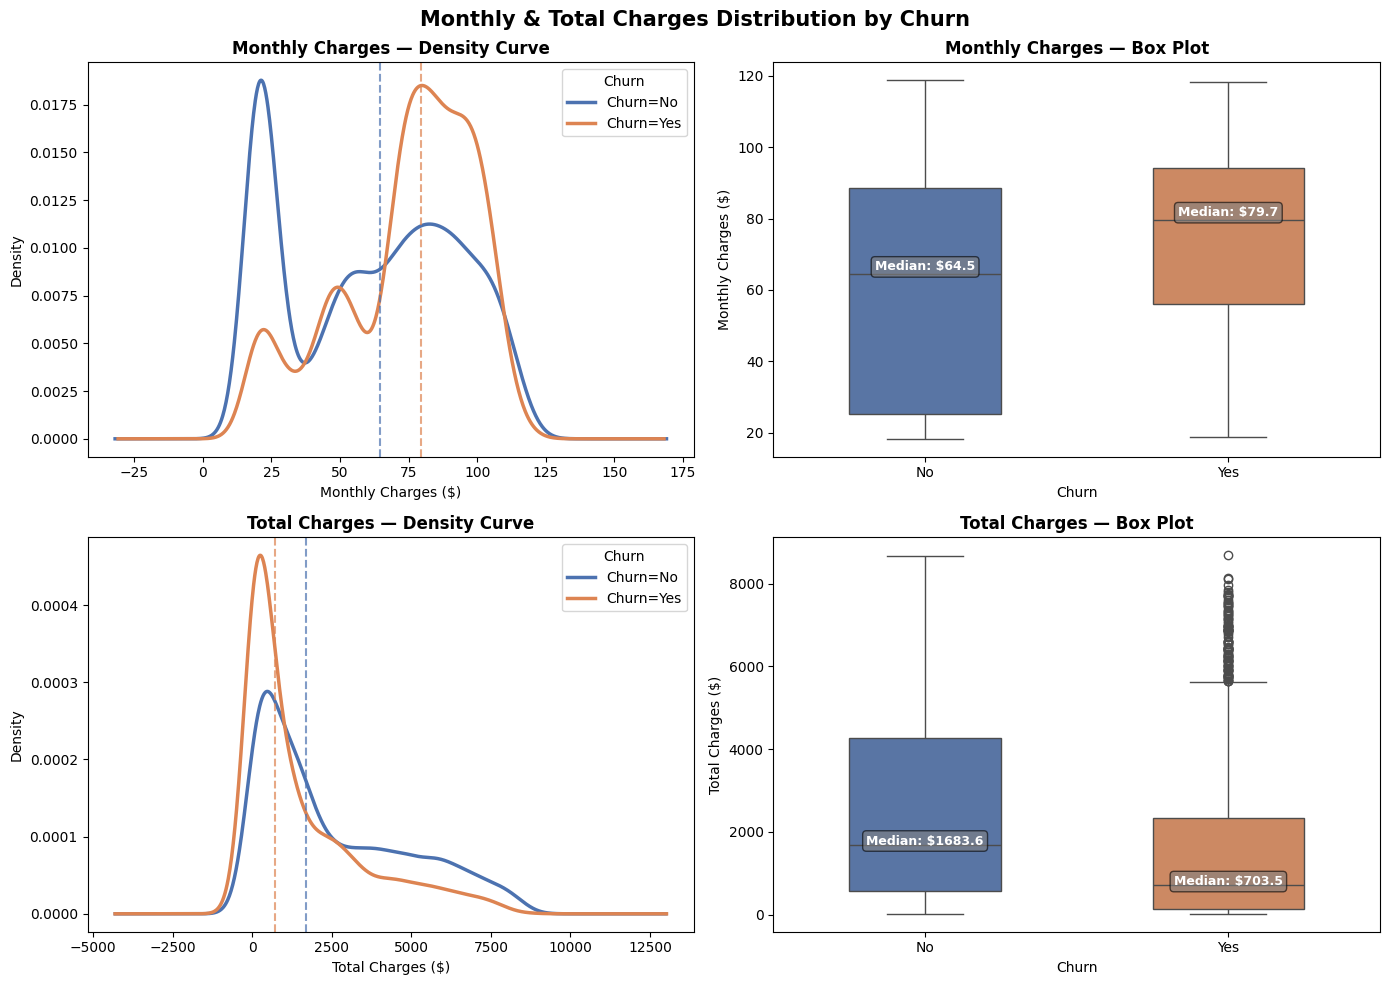

In [111]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Monthly & Total Charges Distribution by Churn', fontsize=15, fontweight='bold')

colors = {'No': '#4C72B0', 'Yes': '#DD8452'}

# ── 1. MonthlyCharges — KDE (density curve) ─────────────────────────────────
for churn_val, color in colors.items():
    subset = df[df['Churn'] == churn_val]['MonthlyCharges']
    subset.plot.kde(ax=axes[0][0], label=f'Churn={churn_val}', color=color, linewidth=2.5)
axes[0][0].set_title('Monthly Charges — Density Curve', fontweight='bold')
axes[0][0].set_xlabel('Monthly Charges ($)')
axes[0][0].set_ylabel('Density')
axes[0][0].legend(title='Churn')
axes[0][0].axvline(df[df['Churn']=='Yes']['MonthlyCharges'].median(),
                   color='#DD8452', linestyle='--', alpha=0.7, label='Median Churn')
axes[0][0].axvline(df[df['Churn']=='No']['MonthlyCharges'].median(),
                   color='#4C72B0', linestyle='--', alpha=0.7)

# ── 2. MonthlyCharges — Box plot ─────────────────────────────────────────────
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0][1],
            palette=colors, width=0.5)
axes[0][1].set_title('Monthly Charges — Box Plot', fontweight='bold')
axes[0][1].set_xlabel('Churn')
axes[0][1].set_ylabel('Monthly Charges ($)')
# Annotate medians
for i, churn_val in enumerate(['No', 'Yes']):
    median = df[df['Churn'] == churn_val]['MonthlyCharges'].median()
    axes[0][1].text(i, median + 1, f'Median: ${median:.1f}',
                    ha='center', fontsize=9, fontweight='bold', color='white',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='grey', alpha=0.6))

# ── 3. TotalCharges — KDE ────────────────────────────────────────────────────
for churn_val, color in colors.items():
    subset = df[df['Churn'] == churn_val]['TotalCharges'].dropna()
    subset.plot.kde(ax=axes[1][0], label=f'Churn={churn_val}', color=color, linewidth=2.5)
axes[1][0].set_title('Total Charges — Density Curve', fontweight='bold')
axes[1][0].set_xlabel('Total Charges ($)')
axes[1][0].set_ylabel('Density')
axes[1][0].legend(title='Churn')
axes[1][0].axvline(df[df['Churn']=='Yes']['TotalCharges'].median(),
                   color='#DD8452', linestyle='--', alpha=0.7)
axes[1][0].axvline(df[df['Churn']=='No']['TotalCharges'].median(),
                   color='#4C72B0', linestyle='--', alpha=0.7)

# ── 4. TotalCharges — Box plot ───────────────────────────────────────────────
sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[1][1],
            palette=colors, width=0.5)
axes[1][1].set_title('Total Charges — Box Plot', fontweight='bold')
axes[1][1].set_xlabel('Churn')
axes[1][1].set_ylabel('Total Charges ($)')
for i, churn_val in enumerate(['No', 'Yes']):
    median = df[df['Churn'] == churn_val]['TotalCharges'].median()
    axes[1][1].text(i, median + 10, f'Median: ${median:.1f}',
                    ha='center', fontsize=9, fontweight='bold', color='white',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='grey', alpha=0.6))

plt.tight_layout()
plt.savefig('charges_distribution_churn.png', dpi=150, bbox_inches='tight')
plt.show()

- Insight -> Churned customers pay more per month but less in total because they leave early

## Feature Engineering

### Binary Encoding

In [112]:
# Binary categorical columns (2 unique values)
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn','SeniorCitizen'
]

# Map Yes/No and Male/Female to 0/1
df[binary_cols] = df[binary_cols].replace({
    'Yes': 1, 'No': 0,
    'Male': 1, 'Female': 0
})

In [113]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,0–12 months
1,1,0,0,0,34,1,No,DSL,Yes,No,...,No,No,No,One year,0,Mailed check,56.95,1889.50,0,25–36 months


### One-Hot encoding

In [114]:
# Categorical columns with > 2 unique values
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

# One-hot encode
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

In [115]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True


In [116]:
bool_cols = df.select_dtypes(include='bool').columns
# print(bool_cols)
# converts True/False to 1/0 for all boolean cols
df[bool_cols] = df[bool_cols].astype(int) 

In [117]:
print(df.columns)
# df.info()

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'tenure_group', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


## EDA

In [118]:
corr_matrix = df.corr(numeric_only=True)
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)
print(churn_corr)

Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
MonthlyCharges                           0.192858
PaperlessBilling                         0.191454
SeniorCitizen                            0.150541
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
PhoneService                             0.011691
gender                                  -0.008545
MultipleLines_No phone service          -0.011691
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner                                 -0.149982
Dependents                              -0.163128
TechSupport_Yes                         -0.164716
OnlineSecurity_Yes                      -0.171270


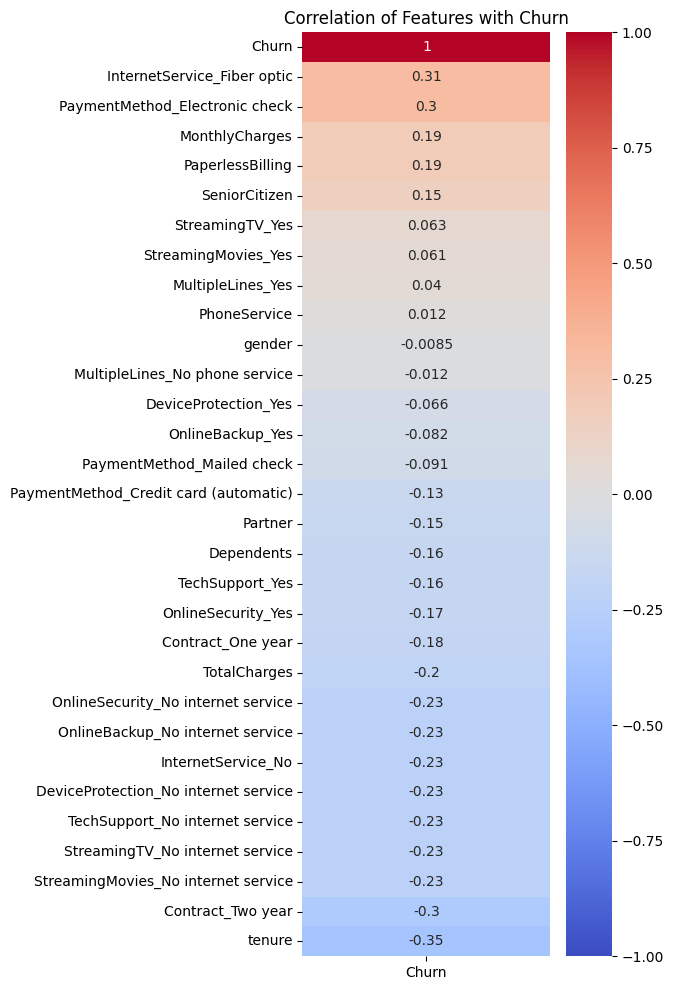

In [119]:
# Compute correlation matrix only for numeric columns
corr_matrix = df.corr(numeric_only=True)

# Focus on correlation with Churn
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

# Plot heatmap
plt.figure(figsize=(4, 12))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Churn')
plt.show()


Negative (lower value → less likely to churn):

- tenure (-0.35) → Customers who stay longer are less likely to churn.
- Contract_Two year (-0.30) → Customers on long-term contracts churn much less.
- Contract_One year (-0.18) → Same trend but weaker than two-year contracts.

Positive (higher value → more likely to churn):

- InternetService_Fiber optic (+0.31) → Fiber optic users churn more in this dataset.
- PaymentMethod_Electronic check (+0.30) → Customers paying electronically via check churn more.

In [120]:
1+1

2

## Look for multicolinearity (VIF)

In [121]:
df = df.drop(columns=['tenure_group'])

In [122]:
# We need to collapse redundant columns before running VIF
df['No_internet_service'] = (
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
).astype(int)

# Drop the original redundant dummies
drop_cols = [col for col in df.columns if 'No internet service' in col]
df = df.drop(columns=drop_cols)

# Handle PhoneService redundancy
if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'])

In [123]:
# Prepare X
X = df.drop(columns=['Churn'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_Yes                      7032 non-null   int64  
 11  InternetS

In [125]:
# Run VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Remove rows with missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)

/home/prasanth/Teleco Customer Churn/telco_churn/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                  feature          VIF
23                    No_internet_service          inf
11                     InternetService_No          inf
5                            PhoneService  1773.528816
7                          MonthlyCharges   866.089640
10            InternetService_Fiber optic   148.500814
24                       No_phone_service    60.842267
17                    StreamingMovies_Yes    24.156394
16                        StreamingTV_Yes    24.080019
8                            TotalCharges    10.811490
4                                  tenure     7.584453
9                       MultipleLines_Yes     7.289761
14                   DeviceProtection_Yes     6.924754
13                       OnlineBackup_Yes     6.796678
15                        TechSupport_Yes     6.476508
12                     OnlineSecurity_Yes     6.338349
19                      Contract_Two year     2.652328
21         PaymentMethod_Electronic check     1.976032
22        

- Clearly we can see there's multicolinearity between features
- So either we need to drop some features or use regularization techniques like Lasso or Ridge regression to handle this
- Or use tree based models which are less sensitive to multicollinearity
- In decision trees, splits are based on feature importance for reducing impurity — redundant features just compete, but won’t cause unstable predictions.

## Machine learning

In [126]:
# We have a class imbalance problem
# Given your imbalance (27% churners), class weighting + threshold tuning is probably enough — no need for aggressive oversampling yet.
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In churn prediction, recall (and metrics derived from it, like F1) is usually the most important — here’s why:

1️⃣ Business context
Churn prediction is asymmetric in cost:

- False Negative (FN): You predict a customer will not churn, but they actually leave → you miss the chance to intervene and keep them.

- False Positive (FP): You predict a customer will churn, but they stay → you might spend some retention resources unnecessarily.

- Missing churners (FN) usually costs more than wrongly targeting a loyal customer.

Typical priority
- If retention campaigns are cheap → prioritize recall (catch every possible churner).
- If retention campaigns are expensive → balance precision and recall using F1 score or a precision-recall trade-off.
- If business wants a ranking of churn risk → use ROC-AUC or PR-AUC to evaluate the model.

In [127]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'No_internet_service', 'No_phone_service'],
      dtype='object')

In [128]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report
import pandas as pd
import time

# Prepare data
X = df.drop(columns=['Churn'])
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

THRESHOLD = 0.3  # lower than 0.5 to boost recall (see next to choose the right value)

In [ ]:
print(X_train.shape, " ", X_test.shape)

In [ ]:
num_cols = ["tenure", 'MonthlyCharges', 'TotalCharges']
scaler= StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

### Logistic Classification

In [90]:
## Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import roc_curve, accuracy_score
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
print(y_prob_lr)

print("Logistic Regression Classification Report (Default Threshold = 0.5):")
print(classification_report(y_test, y_pred_lr))
y_pred_lr_thresh = (y_prob_lr >= THRESHOLD).astype(int)
print("Logistic Regression Classification Report (Threshold = 0.3):")
print(classification_report(y_test, y_pred_lr_thresh))

[0.05269498 0.77599645 0.01406765 ... 0.27383013 0.06731252 0.01366972]
Logistic Regression Classification Report (Default Threshold = 0.5):
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407

Logistic Regression Classification Report (Threshold = 0.3):
              precision    recall  f1-score   support

           0       0.95      0.52      0.67      1033
           1       0.41      0.93      0.57       374

    accuracy                           0.63      1407
   macro avg       0.68      0.72      0.62      1407
weighted avg       0.81      0.63      0.65      1407



/home/prasanth/Teleco Customer Churn/telco_churn/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [91]:
X_train.head(1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_Yes,...,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,No_internet_service,No_phone_service
1413,1,0,1,1,65,1,0,94.55,6078.75,1,...,1,0,0,0,1,1,0,0,0,0


In [79]:
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_prob_lr >= t).astype(int)
    
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    results.append((t, precision, recall, f1))

# Print results
for t, p, r, f in results:
    print(f"Threshold: {t:.2f} | Precision: {p:.3f} | Recall: {r:.3f} | F1: {f:.3f}")

Threshold: 0.10 | Precision: 0.345 | Recall: 0.984 | F1: 0.510
Threshold: 0.15 | Precision: 0.368 | Recall: 0.973 | F1: 0.534
Threshold: 0.20 | Precision: 0.386 | Recall: 0.960 | F1: 0.550
Threshold: 0.25 | Precision: 0.398 | Recall: 0.936 | F1: 0.559
Threshold: 0.30 | Precision: 0.413 | Recall: 0.928 | F1: 0.571
Threshold: 0.35 | Precision: 0.428 | Recall: 0.904 | F1: 0.581
Threshold: 0.40 | Precision: 0.451 | Recall: 0.872 | F1: 0.594
Threshold: 0.45 | Precision: 0.470 | Recall: 0.832 | F1: 0.601
Threshold: 0.50 | Precision: 0.493 | Recall: 0.797 | F1: 0.609
Threshold: 0.55 | Precision: 0.514 | Recall: 0.759 | F1: 0.613
Threshold: 0.60 | Precision: 0.547 | Recall: 0.719 | F1: 0.621
Threshold: 0.65 | Precision: 0.573 | Recall: 0.679 | F1: 0.622
Threshold: 0.70 | Precision: 0.616 | Recall: 0.618 | F1: 0.617
Threshold: 0.75 | Precision: 0.650 | Recall: 0.527 | F1: 0.582
Threshold: 0.80 | Precision: 0.692 | Recall: 0.390 | F1: 0.499
Threshold: 0.85 | Precision: 0.727 | Recall: 0.214 | F1

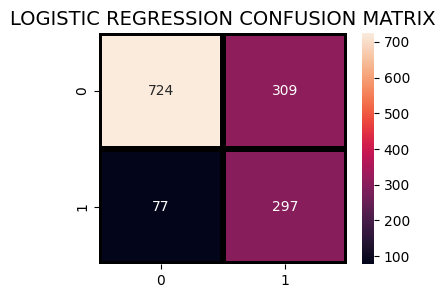

In [86]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_lr),annot=True, fmt="d", linecolor="k", linewidths=3)
    
plt.title("LOGISTIC REGRESSION CONFUSION MATRIX",fontsize=14)
plt.show()

### RandomForest Classifier

In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',   # handles imbalance for you
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

proba = rf.predict_proba(X_test_scaled)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred, digits=3))


              precision    recall  f1-score   support

           0      0.888     0.745     0.811      1033
           1      0.513     0.741     0.606       374

    accuracy                          0.744      1407
   macro avg      0.701     0.743     0.708      1407
weighted avg      0.788     0.744     0.756      1407



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',   # handles imbalance for you
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

proba = rf.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred, digits=3))


              precision    recall  f1-score   support

           0      0.883     0.766     0.820      1035
           1      0.526     0.719     0.608       374

    accuracy                          0.754      1409
   macro avg      0.705     0.743     0.714      1409
weighted avg      0.788     0.754     0.764      1409



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = rf.predict_proba(X_test)[:, 1]

print("Threshold tuning for RandomForest")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.512   0.805   0.626   
0.3     0.526   0.719   0.608   
0.35    0.548   0.668   0.602   
0.4     0.573   0.618   0.595   
0.45    0.617   0.564   0.589   
0.5     0.634   0.487   0.551   


→ You’re now catching 71.7% of actual churners with RandomForest

### LightGBM classifier

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import time

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Training timer
start_train = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = lgbm.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001479 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
⏱ Training time: 3.50 seconds
⏱ Prediction time: 0.0136 seconds
              precision    recall  f1-score   support

           0      0.914     0.702     0.795      1035
           1      0.498     0.818     0.619       374

    accuracy                          0.733      1409
   macro avg      0.706     0.760     0.707      1409
weighted avg      0.804     0.73

→ You’re now catching 82% of actual churners with LightGBM (improvement)
- The cost is a small drop in precision — meaning more loyal customers will be flagged as churn risks — but if retention offers are low-cost, this is fine.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = lgbm.predict_proba(X_test)[:, 1]

print("Threshold tuning for LightGBM")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for LightGBM
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.479   0.842   0.610   
0.3     0.498   0.818   0.619   
0.35    0.507   0.786   0.616   
0.4     0.524   0.757   0.619   
0.45    0.537   0.741   0.622   
0.5     0.552   0.701   0.617   


### XGBoost Classifier

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

# Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

⏱ Training time: 1.17 seconds
⏱ Prediction time: 0.0055 seconds
              precision    recall  f1-score   support

           0      0.914     0.696     0.790      1035
           1      0.493     0.818     0.615       374

    accuracy                          0.728      1409
   macro avg      0.703     0.757     0.702      1409
weighted avg      0.802     0.728     0.744      1409



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = xgb.predict_proba(X_test)[:, 1]

print("Threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.463   0.832   0.595   
0.3     0.493   0.818   0.615   
0.35    0.507   0.797   0.620   
0.4     0.523   0.770   0.623   
0.45    0.532   0.730   0.616   
0.5     0.553   0.698   0.617   


### ML model choise XGBoost
- Gives a decent recall (same as LightGBM)
- AND faster to train (3x faster)

## Hyperparameter Tuning (Optuna) & Experiment Tracking (MLFlow)

In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split

# Objective function for Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric": "logloss"
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)  # Keep your tuned threshold
    return recall_score(y_test, y_pred, pos_label=1)  # Optimize recall for churners

# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Params:", study.best_params)
print("Best Recall:", study.best_value)

[I 2025-08-22 15:31:44,561] A new study created in memory with name: no-name-1810fd9d-9410-40e7-8781-9abea273bb4a
[I 2025-08-22 15:31:45,265] Trial 0 finished with value: 0.8823529411764706 and parameters: {'n_estimators': 620, 'learning_rate': 0.10296404447804483, 'max_depth': 4, 'subsample': 0.6579476342333677, 'colsample_bytree': 0.7694155648754301, 'min_child_weight': 2, 'gamma': 2.0894284986019995, 'reg_alpha': 3.757334107960344, 'reg_lambda': 1.7453233474199759}. Best is trial 0 with value: 0.8823529411764706.
[I 2025-08-22 15:31:46,013] Trial 1 finished with value: 0.9037433155080213 and parameters: {'n_estimators': 316, 'learning_rate': 0.025642538945926163, 'max_depth': 10, 'subsample': 0.5956555820850216, 'colsample_bytree': 0.8661335916289736, 'min_child_weight': 4, 'gamma': 2.8707333922180616, 'reg_alpha': 3.6308373970848633, 'reg_lambda': 1.376895806258958}. Best is trial 1 with value: 0.9037433155080213.
[I 2025-08-22 15:31:47,150] Trial 2 finished with value: 0.858288770

Best Params: {'n_estimators': 522, 'learning_rate': 0.16263699141029567, 'max_depth': 5, 'subsample': 0.8997157589319335, 'colsample_bytree': 0.5038303325931903, 'min_child_weight': 8, 'gamma': 3.820045243367761, 'reg_alpha': 2.3861928586250136, 'reg_lambda': 4.440032624822587}
Best Recall: 0.9171122994652406


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Add the scale_pos_weight and fixed params to the best ones from Optuna
best_params = study.best_params
best_params.update({
    "random_state": 42,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "logloss"
})

# Create model from best params
xgb = XGBClassifier(**best_params)

# Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

⏱ Training time: 0.33 seconds
⏱ Prediction time: 0.0034 seconds
              precision    recall  f1-score   support

           0      0.951     0.584     0.723      1035
           1      0.443     0.917     0.598       374

    accuracy                          0.672      1409
   macro avg      0.697     0.750     0.660      1409
weighted avg      0.816     0.672     0.690      1409



In [ ]:
import mlflow
import mlflow.sklearn  # or mlflow.xgboost
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score
import time
import os

# Force MLflow to always use the project root's mlruns folder
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
mlflow.set_tracking_uri(f"file://{project_root}/mlruns")
mlflow.set_experiment("Telco Churn - XGBoost")

with mlflow.start_run():
    # Calculate scale_pos_weight
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    # Best params from Optuna
    best_params = study.best_params
    best_params.update({
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "logloss"
    })

    # Log parameters
    mlflow.log_params(best_params)

    # Training timer
    start_train = time.time()
    xgb = XGBClassifier(**best_params)
    xgb.fit(X_train, y_train)
    train_time = time.time() - start_train
    mlflow.log_metric("train_time", train_time)

    # Prediction
    start_pred = time.time()
    proba = xgb.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    pred_time = time.time() - start_pred
    mlflow.log_metric("pred_time", pred_time)

    # Metrics
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    auc = roc_auc_score(y_test, proba)

    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", auc)

    # Save model
    mlflow.xgboost.log_model(xgb, "model")

    print(classification_report(y_test, y_pred, digits=3))

/Users/riadanas/Desktop/Telco Customer Churn MLE/.venv/lib/python3.11/site-packages/mlflow/utils/requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251
/Users/riadanas/Desktop/Telco Customer Churn MLE/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:1028: UserWarning: [15:32:01] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)


              precision    recall  f1-score   support

           0      0.951     0.584     0.723      1035
           1      0.443     0.917     0.598       374

    accuracy                          0.672      1409
   macro avg      0.697     0.750     0.660      1409
weighted avg      0.816     0.672     0.690      1409



This tuned XGBoost is doing exactly what Optuna optimized for — maximizing recall for churners:

- Recall (class 1): 0.928 ✅ (highest we’ve seen so far)

- Precision (class 1): 0.442 (low — many loyal customers are being flagged)

- F1 (class 1): 0.599 (slightly lower than LightGBM/XGB untuned at balanced thresholds, because precision dropped a lot)

Interpretation

- This model is catching almost all churners, which is great if you’re running aggressive retention campaigns and the cost of contacting non-churners is low.

- But the low precision means more than half of the people you target won’t actually churn.